#### Notas de aula: Mecânica Quântica, Autor: Jonas Maziero, Departamento de Física, UFSM

In [1]:
%run init.ipynb

## Problema de dois estados (na representação de interação)
Consideremos o Hamiltoniano dependente do tempo $H_{t}=H_{c}+V_{t}$, onde
\begin{align}
H_{c} & = E_{1}^{c} |E_{1}^{c}\rangle\langle E_{1}^{c}| + E_{2}^{c} |E_{2}^{c}\rangle\langle E_{2}^{c}| \\
      & =: e_{1} |1\rangle\langle 1| + e_{2} |2\rangle\langle 2| \\
      & = \begin{bmatrix} e_{1} & 0 \\ 0 & e_{2} \end{bmatrix}, \\
V_{t} & = \gamma\left(e^{i\omega t} |1\rangle\langle 2| + e^{-i\omega t} |2\rangle\langle 1| \right) \\
      & = \begin{bmatrix} 0 & \gamma e^{i\omega t} \\ \gamma e^{-i\omega t} & 0 \end{bmatrix}\\
      & = \gamma[\cos(\omega t)\sigma_{x}-\sin(\omega t)\sigma_{y}],
\end{align}
com $e_{2}>e_{1}$ e as representações são feitas na base $\{|j\rangle\}_{j=1}^{2}$. Note que $\gamma$ dita a intensidade da interação e a frequência de mudanças temporais que ocorrerão neste sistema. Vale observar também que
\begin{equation}
H_{t} = \begin{bmatrix} e_{1} & \gamma e^{i\omega t} \\ \gamma e^{-i\omega t} & e_{2} \end{bmatrix}
\end{equation}
é a matriz 2x2 Hermitiana mais geral que podemos construir. Em relação ao tempo, o que poderíamos fazer de mais geral é usar $e_{j}(t)$, $\gamma(t)$ e $\omega(t)$.

_OBS:_ Verifiquemos que esse Hamiltoniano não comuta em tempos diferentes, e por conseguinte não poderemos utilizar $U_{t} = e^{-\frac{i}{\hbar}\int_{0}^{t}H(t')dt'}$. E esse é um exemplo de situação onde é útil usar a representação de interação.

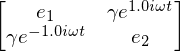

In [2]:
w, e1, e2, t, t1, t2, g = symbols('omega e_{1} e_{2} t t_{1} t_{2} gamma')
def H(t):
    return Matrix([[e1,g*exp(1j*w*t)],[g*exp(-1j*w*t),e2]])
def comm(x,y):
    return x*y - y*x
H(t)

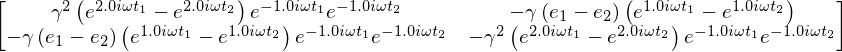

In [3]:
factor(comm(H(t1),H(t2)))

Vemos assim que $[H_{t},H_{t'}]=\mathbb{0}$ se e somente se $t=t'$.

Lembrando, na RI escrevemos $|\psi_{t}^{I}\rangle = \sum_{j=1}^{2} c_{j}(t)|{j}\rangle$ e chegamos na eq. matricial para os coeficientes
\begin{align}
i\hbar 
\begin{bmatrix}
\partial_{t}c_{1} \\ \partial_{t}c_{2}
\end{bmatrix}
& = 
\begin{bmatrix}
V_{11} & V_{12}e^{i\omega_{12}t} \\
V_{21}e^{i\omega_{21}t} & V_{22} \\
\end{bmatrix}
\begin{bmatrix}
c_{1} \\ c_{2}
\end{bmatrix} \\
& = 
\begin{bmatrix}
0 & \gamma e^{i\omega t}e^{-i\omega_{21}t} \\
\gamma e^{-i\omega t}e^{i\omega_{21}t} & 0 \\
\end{bmatrix}
\begin{bmatrix}
c_{1} \\ c_{2}
\end{bmatrix} \\
& = 
\begin{bmatrix}
\gamma e^{i(\omega-\omega_{21}) t}c_{2} \\ \gamma e^{-i(\omega-\omega_{21}) t}c_{1}
\end{bmatrix}
,
\end{align}
onde para o presente Hamiltoniano usamos que $\omega_{21} = -\omega_{12} = e_{2}-e_{1}$ e $V_{11} = V_{22} = 0$ e $V_{12} = V_{21}^{*} = \gamma e^{i\omega t}$.

Para desacoplar esse sistema de equações lineares, vamos tomar a derivada temporal
\begin{align}
i\hbar\partial_{tt}c_{1} & = i\gamma(\omega-\omega_{21})e^{i(\omega-\omega_{21})t}c_{2} + \gamma e^{i(\omega-\omega_{21})t}\frac{i\hbar}{i\hbar}\partial_{t}c_{2}, \\
i\hbar\partial_{tt}c_{2} & = -i\gamma(\omega-\omega_{21})e^{-i(\omega-\omega_{21})t}c_{1} + \gamma e^{-i(\omega-\omega_{21})t}\frac{i\hbar}{i\hbar}\partial_{t}c_{1}.
\end{align}
Usando as eqs. diferenciais de primeira ordem:
\begin{align}
i\hbar\partial_{tt}c_{1} & = i(\omega-\omega_{21})i\hbar\partial_{t}c_{1} + \gamma e^{i(\omega-\omega_{21})t}\frac{1}{i\hbar}\gamma e^{-i(\omega-\omega_{21}) t}c_{1}, \\
i\hbar\partial_{tt}c_{2} & = -i(\omega-\omega_{21})i\hbar\partial_{t}c_{2} + \gamma e^{-i(\omega-\omega_{21})t}\frac{1}{i\hbar}\gamma e^{i(\omega-\omega_{21}) t}c_{2}.
\end{align}
Rearranjamos essas eqs. para obter o seguinte conjunto de _eqs. diferenciais de segunda ordem mas desacopladas_:
\begin{align}
& \partial_{tt}c_{1} - i(\omega-\omega_{21})\partial_{t}c_{1} + \frac{\gamma^{2}}{\hbar^{2}}c_{1} = 0, \\
& \partial_{tt}c_{2} + i(\omega-\omega_{21})\partial_{t}c_{2} + \frac{\gamma^{2}}{\hbar^{2}}c_{2} = 0.
\end{align}
Abaixo vamos fazer uso do sympy para obter a _solução_ desse sistema.

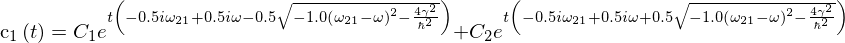

In [4]:
w21, hb = symbols('\omega_{21} \hbar')
c1 = Function('c1')
dsolve(Derivative(c1(t),t,t) - 1j*(w-w21)*Derivative(c1(t),t) + (g**2/hb**2)*c1(t), c1(t))

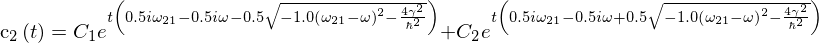

In [5]:
c2 = Function('c2')
dsolve(diff(c2(t),t,t) + 1j*(w-w21)*diff(c2(t),t) + (g**2/hb**2)*c2(t), c2(t))

__Soluções__ gerais para os coeficientes: <br>
Definindo
\begin{equation}
\xi := \sqrt{\frac{\gamma^{2}}{\hbar^{2}}+\left(\frac{\omega-\omega_{21}}{2}\right)^{2}}. 
\end{equation}
teremos
\begin{align}
c_{1}(t) & = e^{i(\omega-\omega_{21})t/2}\left(C_{1} e^{-i\xi t} + C_{2}e^{i\xi t}\right), \\
         & = e^{i(\omega-\omega_{21})t/2}\left[(C_{1}+C_{2})\cos\xi t + i(C_{2}-C_{1})\sin\xi t\right], \\
         & =: e^{i(\omega-\omega_{21})t/2}\left(k_{1}\sin\xi t + k_{2}\cos\xi t \right), \\
c_{2}(t) & = e^{-i(\omega-\omega_{21})t/2}\left(k_{3}\sin\xi t + k_{4}\cos\xi t \right),
\end{align}
As constantes $\{k_{j}\}_{j=1}^{4}$ deve ser determinadas pelas condições iniciais e de normalização.

Vamos assumir que o sistema está _inicialmente_ no estado fundamental do Hamiltoniano independente do tempo $H_{c}$, i.e.,
\begin{equation}
|\psi_{0}^{I}\rangle = |\psi^{s}\rangle = |1\rangle.
\end{equation}
Nesse caso, devemos ter
\begin{align}
c_{1}(0) & = e^{0}\left(k_{1}\sin(0) + k_{2}\cos(0)\right) = k_{2} = 1, \\
c_{2}(0) & = e^{0}\left(k_{3}\sin(0) + k_{4}\cos(0)\right) = k_{4} = 0.
\end{align}
Vem assim que
\begin{equation}
c_{2}(t) = e^{-i(\omega-\omega_{21})t/2}k_{3}\sin\xi t.
\end{equation}
Para facilitar a solução desse problema, usamos uma das equações do sistema original, $i\hbar\partial_{t}c_{2}(t)= \gamma e^{-i(\omega-\omega_{21}) t}c_{1}(t)$, para escrever
\begin{align}
c_{1}(t) & = \gamma^{-1}e^{i(\omega-\omega_{21}) t}i\hbar\partial_{t}c_{2}(t) \\
         & = \gamma^{-1}e^{i(\omega-\omega_{21}) t}i\hbar\left(-i\frac{\omega-\omega_{21}}{2}e^{-i(\omega-\omega_{21})t/2}k_{3}\sin\xi t  + \xi e^{-i(\omega-\omega_{21})t/2}k_{3}\cos\xi t\right) \\
         & = \gamma^{-1}i\hbar k_{3}e^{i(\omega-\omega_{21}) t/2}\left(-i\frac{\omega-\omega_{21}}{2}\sin\xi t  + \xi\cos\xi t\right).
\end{align}

Agora aplicamos a normalização do estado:
\begin{align}
& |c_{1}(t)|^{2} + |c_{2}(t)|^{2} = 1 \\
& \gamma^{-2}\hbar^{2} k_{3}^{2}\left(-i\frac{\omega-\omega_{21}}{2}\sin\xi t  + \xi\cos\xi t\right)\left(i\frac{\omega-\omega_{21}}{2}\sin\xi t  + \xi\cos\xi t\right) + k_{3}^{2}\sin^{2}\xi t = 1 \\
& \gamma^{-2}\hbar^{2} k_{3}^{2}\left(\left(\frac{\omega-\omega_{21}}{2}\right)^{2}\sin^{2}\xi t  + \xi^{2}\cos^{2}\xi t\right) + k_{3}^{2}\sin^{2}\xi t = 1 \\ 
& k_{3}^{2}\left(\left(\left(\frac{\omega-\omega_{21}}{2}\right)^{2}\sin^{2}\xi t  + \xi^{2}\cos^{2}\xi t\right) + (\gamma^{2}/\hbar^{2})\sin^{2}\xi t \right)= \gamma^{2}/\hbar^{2}.
\end{align}

Assim
\begin{align}
k_{3}^{2} & = \frac{\gamma^{2}/\hbar^{2}}{\left(\left(\frac{\omega-\omega_{21}}{2}\right)^{2}+\frac{\gamma^{2}}{\hbar^{2}}\right)\sin^{2}\xi t  + \xi^{2}\cos^{2}\xi t} \\
          & = \frac{\gamma^{2}/\hbar^{2}}{\xi^{2}\sin^{2}\xi t  + \xi^{2}\cos^{2}\xi t} \\
          & = \frac{\gamma^{2}/\hbar^{2}}{\gamma^{2}/\hbar^{2} + \left(\frac{\omega-\omega_{21}}{2}\right)^{2}} \\
          & = \frac{1}{1 + \left(\frac{\hbar\omega_{21}}{2\gamma}\left(1-\frac{\omega}{\omega_{21}}\right)\right)^{2}}.
\end{align}

Como
\begin{equation}
Pr(2(t)) = |\langle 2|\psi_{t}^{I}\rangle|^{2} = |c_{2}(t)|^{2} = k_{3}^{2}\sin^{2}\xi t,
\end{equation}
primeiramente notamos que as _probabilidades oscilam sinudoisalmente_ com o tempo, com amplitude máxima determinada por $k_{3}$. Ademais, só teremos probabilidade máxima de encontrar o sistema no estado excitado se $\omega=\omega_{21}$ (que resulta em $k_{3}=1$), que é a condição de _ressonância_. Ou seja, o termo dependente do tempo do Hamiltoniano terá eficiência máxima em causar transição entre os níveis de energia quando sua frequência for igual à frequência de Bohr do sistema. A dependência da probabilidade máxima
\begin{equation}
|c_{2}(t)|^{2}_{\max}=k_{3}^{2}
\end{equation}
com a razão entre a as escalas de intensidade das interações $H_{c}$ e de $V_{t}$, i.e., $\hbar\omega_{21}/\gamma$ e entre as frequências "aplicada" e de Bohr pode ser estudada com os gráficos produzidos com o código abaixo.

In [6]:
def pr2(hwog):
    N = 100
    dw = 20/N
    c2m = np.zeros(N, dtype = float)
    wdv = np.zeros(N, dtype = float)
    wd = -9.-dw
    for j in range(0,N):
        wd += dw
        wdv[j] = wd # razão entre as frequências
        c2 = 1.0/(1 + pow((hwog*(1-wd))/2,2))
        c2m[j] = c2
    plt.plot(wdv, c2m, label=r'$|c_{2}(t)|^{2}_{\max}$')
    plt.xlabel(r'$\omega_{21}/\omega$')
    axes = plt.gca()
    axes.set_xlim([-9,11])
    axes.set_ylim([0,1.05])
    plt.legend()
    plt.show()

In [7]:
interactive(pr2, hwog = (1,10))

interactive(children=(IntSlider(value=5, description='hwog', max=10, min=1), Output()), _dom_classes=('widget-…

__Exercício:__ Repita esses cálculos considerando que o estado inicial é $|2\rangle$. Ou seja, nesse caso obtenha $k_{1}$ e $Pr(1(t))$.

### Ressonância magnética de spin
Considera uma partícula de spin 1/2 sujeita ao seguinte campo magnético
\begin{equation}
\vec{B}(t) = B_{0}\hat{k} - B_{1}\left(\hat{i}\cos\omega t - \hat{j}\sin\omega t\right),
\end{equation}
com $B_{0}$ e $B_{1}$ constantes positivas. Note que há um termo constante na direção $z$ e outro termo que gira no plano $xy$. Para esta interação o Hamiltoniano será
\begin{align}
H & = -\vec{\mu}\cdot\vec{B}(t) \\
  & = -\frac{\hbar gq}{4m}\vec{\sigma}\cdot\vec{B}(t) \\
  & = -\frac{\hbar gq B_{0}}{4m}\sigma_{z} + \frac{\hbar gq B_{1}}{4m}(\sigma_{x}\cos\omega t - \sigma_{y}\sin\omega t) \\
  & = -\frac{\hbar\omega_{21}}{2}\sigma_{z} + \gamma(\sigma_{x}\cos\omega t - \sigma_{y}\sin\omega t) \\
  & = e_{1}|z_{+}\rangle\langle z_{+}| + e_{2}|z_{-}\rangle\langle z_{-}| + \gamma[(|z_{+}\rangle\langle z_{-}|+|z_{-}\rangle\langle z_{+}|)\cos\omega t - (-i|z_{+}\rangle\langle z_{-}|+i|z_{-}\rangle\langle z_{+}|)\sin\omega t)] \\
  & = H_{c} + \gamma[|z_{+}\rangle\langle z_{-}|(\cos\omega t +i\sin\omega t) + |z_{-}\rangle\langle z_{+}|(\cos\omega t -i\sin\omega t)] \\
  & = H_{c} + \gamma(|z_{+}\rangle\langle z_{-}|e^{i\omega t} + |z_{-}\rangle\langle z_{+}|e^{-i\omega t}) \\
  & = H_{c} + V_{t},
\end{align}
onde definimos $\omega_{21} = gqB_{0}/2m$ e $\gamma = \hbar qgB_{1}/4m$.

Como esse Hamiltoniano é idêntico ao que consideramos na última seção, todos os resultados obtidos lá se aplicam aqui. Sabemos que se $B_{1}=0$ o spin precessará em torno da direção $z$. No entando, se $B_{1}>0$ termos "flips" entre os estados $|z_{+}\rangle\leftrightarrow|z_{-}\rangle$. A freqûencia com que essas transições ocorrerão depende das razões $\gamma/\omega_{21}$ e $\omega/\omega_{21}$ como analizado acima.

### MASER (Microwave Amplification by Stimulated Emission of Radiation)
Alguns sistemas, como e.g. a molécula de amônia, possuem momento de dipolo elétrico, que no regime quântico interage com campos elétricos segundo o Hamiltoniano:
\begin{equation}
H = -\vec{\mu}_{e}\cdot\vec{E}.
\end{equation}
Se experimentos do tipo Stern-Gerlach são feitos com essas partículas (com gradientes de campo elétrico), os resultados são idênticos aqueles obtidos para partículas de spin 1/2. Portando os observáveis e estados são descritos pela "mesma matemática". Por conseguinte, se aplicamos um campo elétrico $\vec{E}(t) = E_{0}\hat{k} - E_{1}\left(\hat{i}\cos\omega t - \hat{j}\sin\omega t\right)$ podemos obter transições entre os estados de momento de dipolo elétrico, tal qual o caso da ressonância magnética da última seção.

No caso da amônia $\mathrm{NH_{3}}$, a frequência de Bohr $\omega_{21}$ está no intervalo de microondas ($\nu=(300\text{ MHz} - 300\text{ GHz}) \text{ ou } \lambda = (100\text{ cm} - 0,1\text{ cm})$). O procedimento para obter o MASER é o seguinte. Primeiro faz-se as molécuals passar por um gradiente de campo elétrico na direção $z$, "selecionando" aquelas que são desviadas pra baixo naquela direção. Depois faz-se essas moléculas passar por uma cavidade onde aplica-se um campo oscilante no plano $xy$, como o descrito na equação acima, e na condição de ressonância ($\omega=\omega_{21}$). Pode-se verificar que se a cavidade é construída de forma que as moléculas passam um tempo
\begin{equation}
t_{opt} = \frac{\pi\hbar}{2\gamma},
\end{equation}
todas as moléculas terão decaído para o estado fundamental e emitido radiação de microondas antes de sair da cavidade. Isso fará com que a radiação de microondas aí seja amplificada, e isso se deve ao estímulo do campo externo.

Para verificar que o tempo é dado como acima, notamos que (__exercício__) $k_{1}(\omega = \omega_{21}) = 1$ e portanto (__exercício__) $Pr(1(t)) = k_{1}^{2}\sin^{2}\xi t = \sin^{2}\gamma t/\hbar$, que é máxima quando $\gamma t/\hbar=(2j+1)\pi/2$ para $j=0,1,2,3,\dots$. Para $j=0$ obtemos a expressão acima para o menor tempo necessário para que $Pr(1(t))=1$.